BASE DE DADOS
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

ERRO ABSOLUTO MÉDIO
9079.649028580896

TABELA DE PREVISÕES
     Valor_Real  Valor_Previsto
0    9095.06825    13479.060198
1    5272.17580    11760.139427
2   29330.98315    17121.153895
3    9301.89355    14541.043720
4   33750.29180     8504.099299
5    4536.25900    16265.687282
6    2117.33885     5348.214564
7   14210.53595    20818.958231
8    3732.62510     5656.258996
9   10264.44210    16216.354628
10  18259.21600    10425.165940
11   7256.72310    14379.945307
12   3947.41310    10654.290147
13  46151.12450    20112.916769
14  48673.55880    20914.513902
15  44202.65360    18556.02979

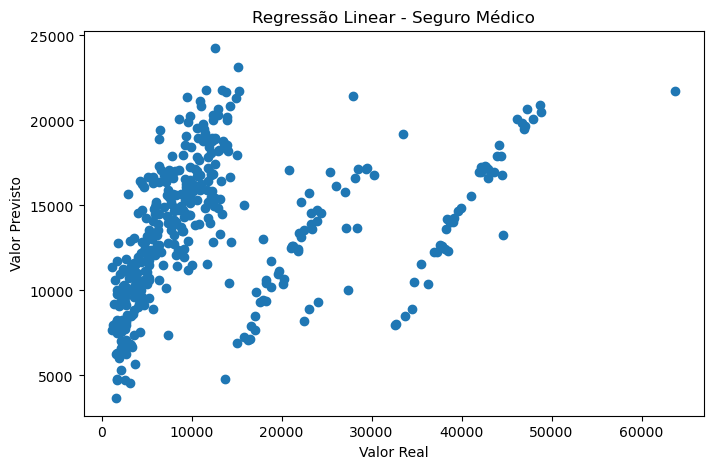

In [ ]:
# Algoritmo: Regressão Linear

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Base: Calcula valor do seguro médico

url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"

df = pd.read_csv(url)

print("BASE DE DADOS")
print(df.head())

# Selecionar apenas colunas numéricas: idade, indice de massa corporal, cobertura de filhos e a saída que é o valro do seguro

X = df[['age', 'bmi', 'children']]
y = df['charges']

# Dividir treino e teste

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# Cria o modelo e Treina
modelo = LinearRegression()
modelo.fit(X_treino, y_treino)

# Calculo das previsões
previsoes = modelo.predict(X_teste)

# Avaliação do modelo
print("\nERRO ABSOLUTO MÉDIO")
print(mean_absolute_error(y_teste, previsoes))

resultado = pd.DataFrame({
    'Valor_Real': y_teste.values,
    'Valor_Previsto': previsoes
})

print("\nTABELA DE PREVISÕES")
print(resultado.head(20))

# Gráfico

plt.figure(figsize=(8,5))
plt.scatter(y_teste, previsoes)
plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title("Regressão Linear - Seguro Médico")
plt.show()